In [ ]:
# Step 1: Libraries
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from google.colab import files
from networkx.algorithms.community import greedy_modularity_communities

# Step 2: file CSV
uploaded = files.upload()

# Step 3: Read file
df = pd.read_csv(next(iter(uploaded)))
df.head()

# Step 4: Create a directed graph
G = nx.DiGraph()
edges = list(zip(df['consumer'], df['resource']))
G.add_edges_from(edges)

# Step 5: Calculate trophic level
def trophic_levels(graph):
    levels = {}
    for node in nx.topological_sort(graph):
        preds = list(graph.predecessors(node))
        if not preds:
            levels[node] = 0
        else:
            levels[node] = 1 + max(levels[p] for p in preds if p in levels)
    return levels

levels = trophic_levels(G)

def hierarchy_pos(G, trophic_levels):

    # Group nodes by level
    levels = {}
    for node, level in trophic_levels.items():
        levels.setdefault(round(level, 2), []).append(node)

    pos = {}
    y_gap = 1
    x_gap = 1
    for i, (level, nodes) in enumerate(sorted(levels.items(), reverse=True)):
        x_positions = np.linspace(0, x_gap * (len(nodes) - 1), len(nodes))
        for j, node in enumerate(nodes):
            pos[node] = (x_positions[j], -i * y_gap)  # Y inverso para que nivel alto arriba
    return pos

Saving FW_lagoon - trophic links.csv to FW_lagoon - trophic links.csv


/tmp/ipython-input-2628207427.py:162: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


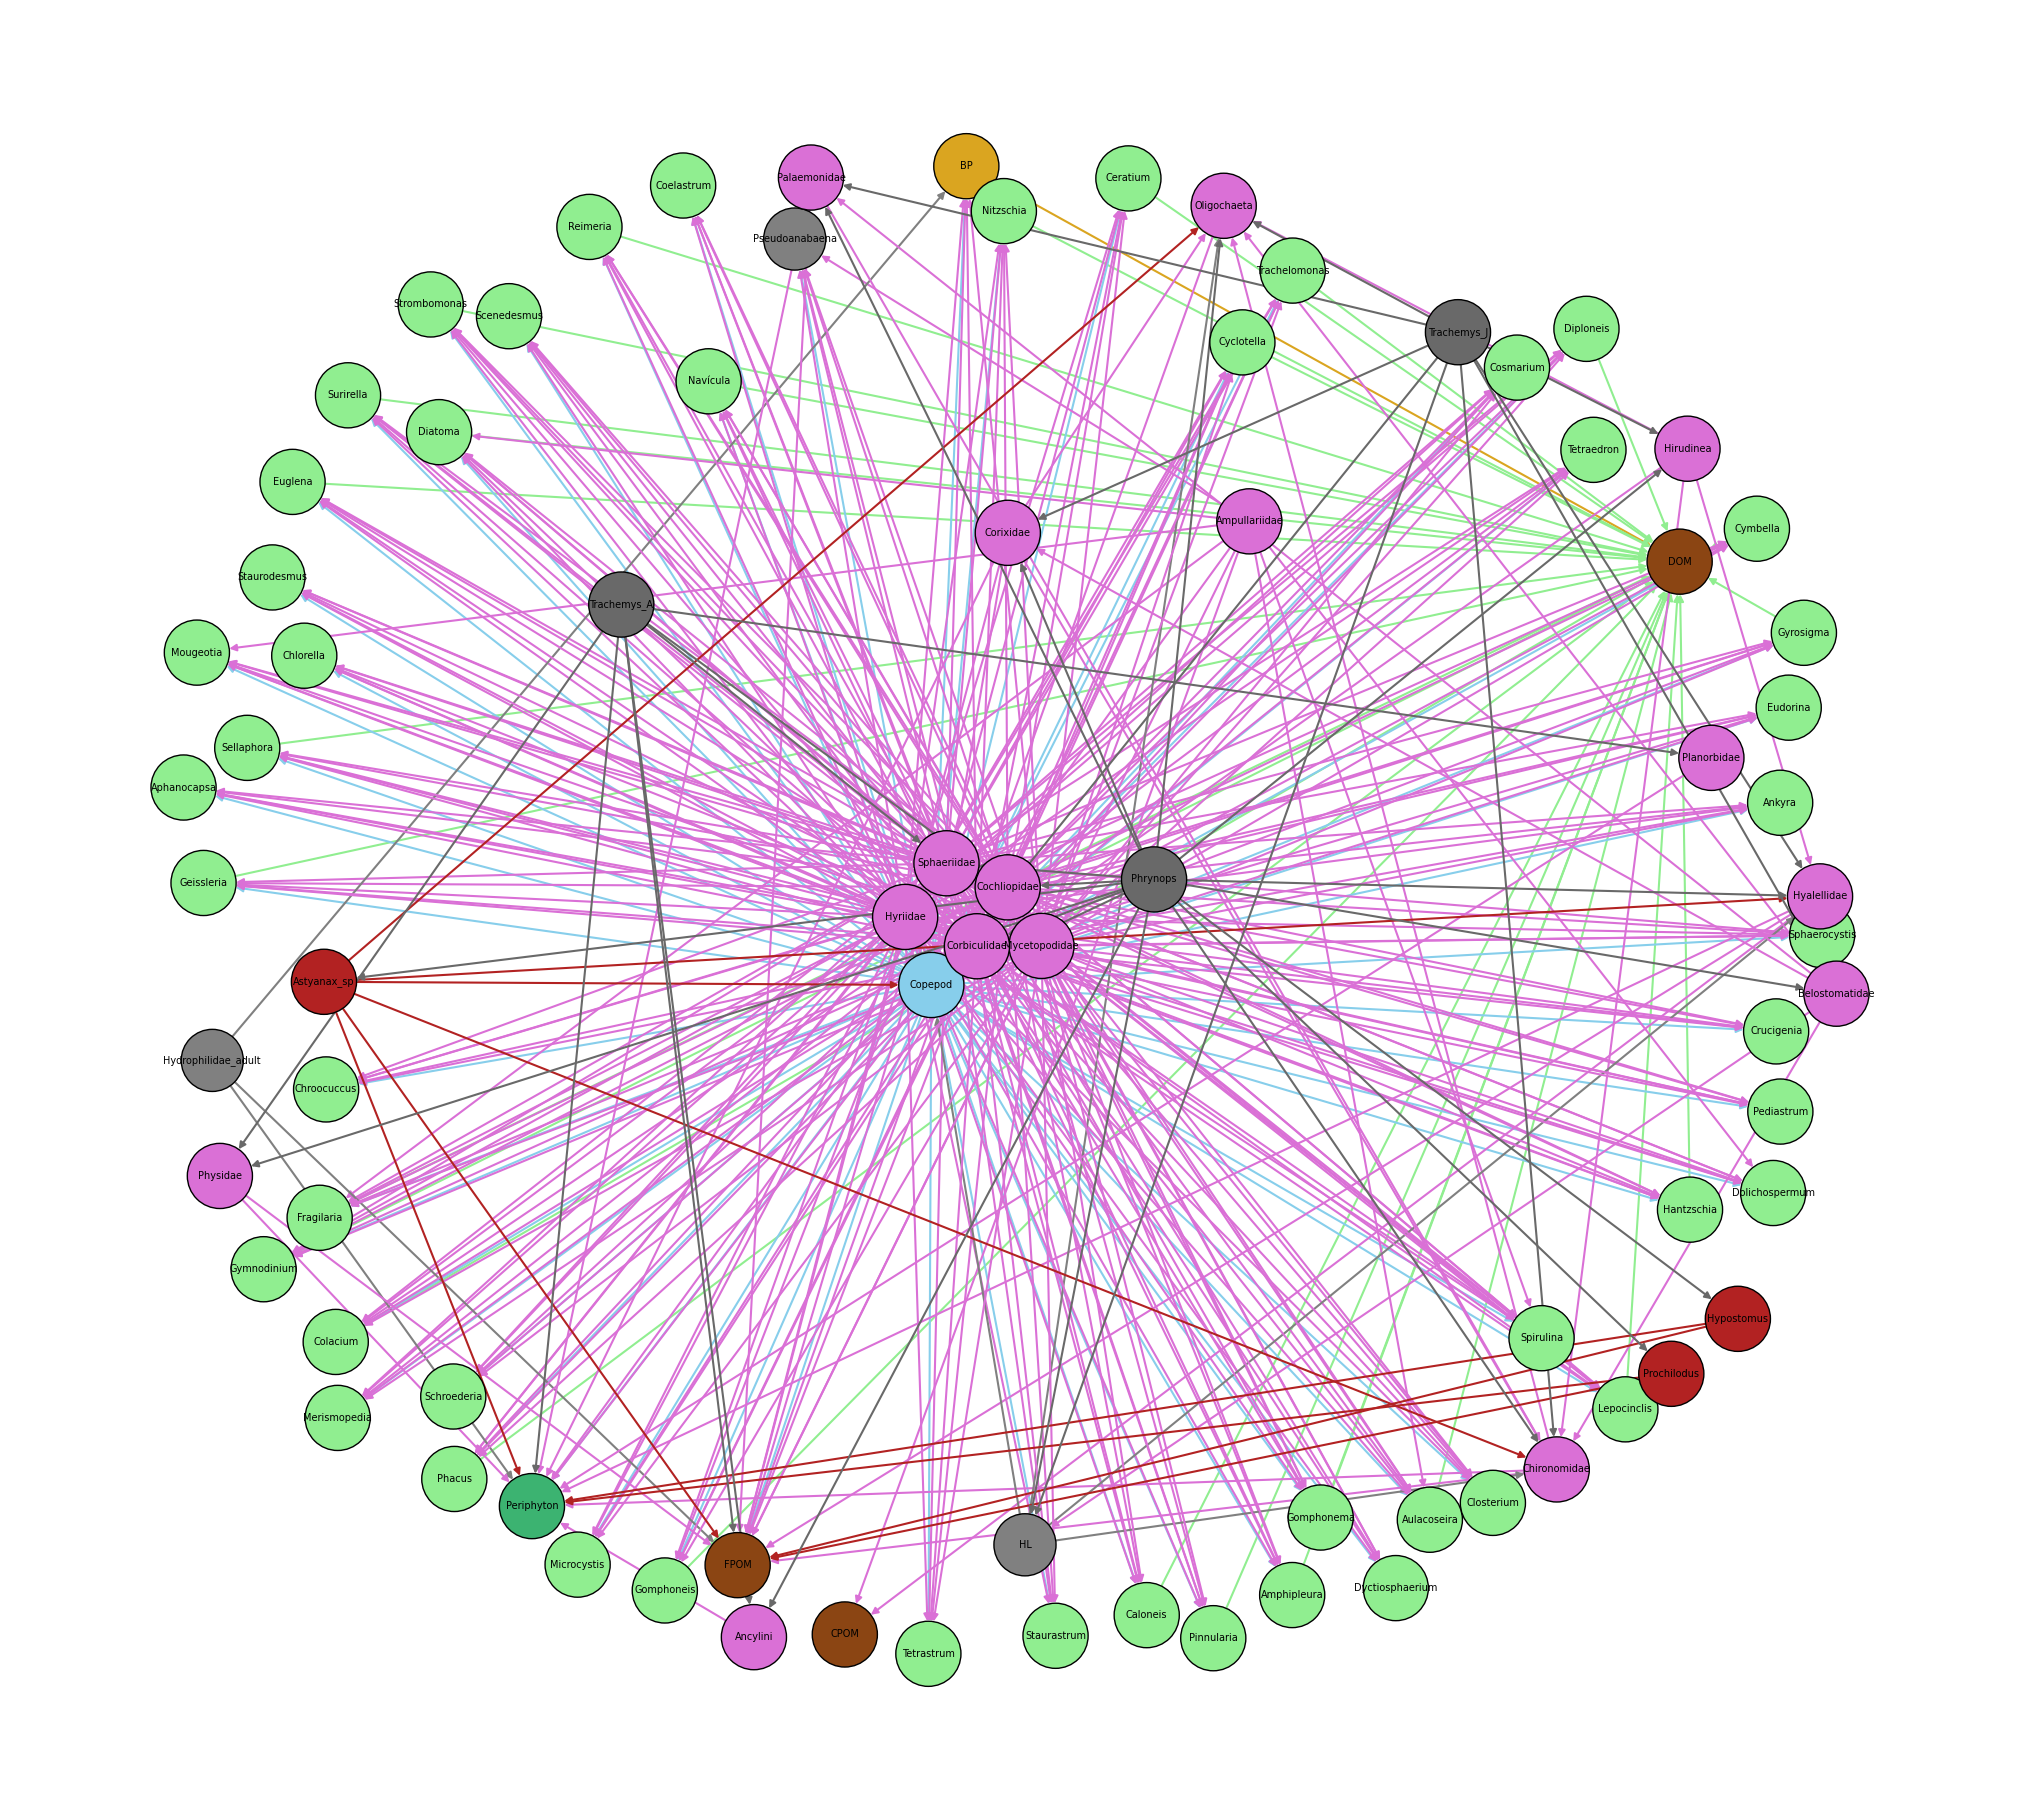

In [ ]:
# Calculate trophc levels
#trophic_levels = trophic_levels(G)

# Create hierarchical layout
#pos = hierarchy_pos(G, trophic_levels)

# Step 6: Node names
label_alias = {
    "Bacterioplankton": "BP",
    "Hydrophilidae_larvae" : "HL",
    "Prochilodus_lineatus" : "Prochilodus",
    "Hypostomus_commersoni" : "Hypostomus",
    "Trachemys_dorbigni_juvenile" : "Trachemys_J",
    "Trachemys_dorbigni_adult" : "Trachemys_A",
    "Phrynops_hilarii" : "Phrynops"
}


grupo_nodo = {
    "DOM": "detritus",
    "FPOM": "detritus",
    "CPOM": "detritus",
    "Bacterioplankton" : "microbial heterotroph",
    "Pediastrum" : "phytoplankton",
    "Chlorella": "phytoplankton",
    "Scenedesmus": "phytoplankton",
    "Coelastrum": "phytoplankton",
    "Closterium": "phytoplankton",
    "Mougeotia": "phytoplankton",
    "Cosmarium": "phytoplankton",
    "Dyctiosphaerium": "phytoplankton",
    "Staurastrum": "phytoplankton",
    "Eudorina": "phytoplankton",
    "Tetrastrum": "phytoplankton",
    "Schroederia": "phytoplankton",
    "Tetraedron": "phytoplankton",
    "Sphaerocystis": "phytoplankton",
    "Staurodesmus": "phytoplankton",
    "Ankyra": "phytoplankton",
    "Crucigenia": "phytoplankton",
    "Phacus": "phytoplankton",
    "Euglena": "phytoplankton",
    "Trachelomonas": "phytoplankton",
    "Strombomonas": "phytoplankton",
    "Lepocinclis": "phytoplankton",
    "Colacium": "phytoplankton",
    "Navícula": "phytoplankton",
    "Gomphonema": "phytoplankton",
    "Amphipleura": "phytoplankton",
    "Fragilaria": "phytoplankton",
    "Nitzschia": "phytoplankton",
    "Sellaphora": "phytoplankton",
    "Pinnularia": "phytoplankton",
    "Aulacoseira": "phytoplankton",
    "Reimeria": "phytoplankton",
    "Cymbella": "phytoplankton",
    "Gomphoneis": "phytoplankton",
    "Hantzschia": "phytoplankton",
    "Geissleria": "phytoplankton",
    "Surirella": "phytoplankton",
    "Diatoma": "phytoplankton",
    "Cyclotella": "phytoplankton",
    "Caloneis": "phytoplankton",
    "Gyrosigma": "phytoplankton",
    "Diploneis": "phytoplankton",
    "Ceratium": "phytoplankton",
    "Gymnodinium": "phytoplankton",
    "Spirulina": "phytoplankton",
    "Merismopedia": "phytoplankton",
    "Aphanocapsa": "phytoplankton",
    "Chroocuccus": "phytoplankton",
    "Dolichospermum": "phytoplankton",
    "Pseudanabaena": "phytoplankton",
    "Microcystis": "phytoplankton",
    "Periphyton" : "periphyton",
    "Hirudinea": "macroinvertebrate",
    "Oligochaeta": "macroinvertebrate",
    "Ampullariidae": "macroinvertebrate",
    "Sphaeriidae": "macroinvertebrate",
    "Cochliopidae": "macroinvertebrate",
    "Chironomidae": "macroinvertebrate",
    "Hyriidae": "macroinvertebrate",
    "Hydrophilidae larvae": "macroinvertebrate",
    "Hydrophilidae adult": "macroinvertebrate",
    "Belostomatidae": "macroinvertebrate",
    "Mycetopodidae": "macroinvertebrate",
    "Corbiculidae": "macroinvertebrate",
    "Corixidae": "macroinvertebrate",
    "Ancylini": "macroinvertebrate",
    "Hyalellidae": "macroinvertebrate",
    "Palaemonidae": "macroinvertebrate",
    "Planorbidae": "macroinvertebrate",
    "Physidae": "macroinvertebrate",
    "Prochilodus_lineatus": "fish",
    "Astyanax_sp": "fish",
    "Hypostomus_commersoni": "fish",
    "Trachemys_dorbigni_juvenile": "aquatic reptile",
    "Trachemys_dorbigni_adult": "aquatic reptile",
    "Phrynops_hilarii": "aquatic reptile",
    "Copepod" : "consumer"
}

# 📏 Size by functional group
tamaño_grupo = {
    "detritus": 2200,
    "microbial heterotroph": 2200,
    "periphyton": 2200,
    "consumer": 2200,
    "phytoplankton": 2200,
    "macroinvertebrate": 2200,
    "fish": 2200,
    "aquatic reptile": 2200
}

# 🎨 Colour by functional group
colores_grupo = {
    "detritus": "saddlebrown",
    "microbial heterotroph": "goldenrod",
    "periphyton": "mediumseagreen",
    "consumer": "skyblue",
    "phytoplankton": "lightgreen",
    "macroinvertebrate": "orchid",
    "fish": "firebrick",
    "aquatic reptile": "dimgray"
}

# ✅ Size and colour
node_colors = []
node_size = []

for node in G.nodes():
    grupo = grupo_nodo.get(node, "unknown")
    node_colors.append(colores_grupo.get(grupo, "gray"))
    node_size.append(tamaño_grupo.get(grupo, 2000))

# 🎯 Link colour
edge_colors = []
for u, v in G.edges():
    grupo_u = grupo_nodo.get(u, "unknown")
    edge_colors.append(colores_grupo.get(grupo_u, "gray"))

# Step 7: Visualization
plt.figure(figsize=(20, 18))
pos = nx.spring_layout(G, seed=42, k=1.7)  # k más alto = más separación entre nodos para mejorar la visualización
nx.draw(
    G,
    pos,
    with_labels=True,
    labels={n: label_alias.get(n, n) for n in G.nodes()},
    node_color=node_colors,
    node_size=node_size,
    edge_color=edge_colors,
    arrows=True,
    font_size=7,
    #font_weight='bold',
    edgecolors='black',
    width=1.5
)
#plt.title("Structural food web", fontsize=14)
plt.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
# Step 8: Topological metrics
print("📊 Metrics of food web\n")
print(f"🔸 Number of nodes: {G.number_of_nodes()}")
print(f"🔸 Number of links: {G.number_of_edges()}")
print(f"🔸 Conectance: {G.number_of_edges() / (G.number_of_nodes()**2):.4f}")

# Degree centrality
deg_centrality = nx.degree_centrality(G)
top_deg = sorted(deg_centrality.items(), key=lambda x: x[1], reverse=True)[:5]
print("\n🔹 Top 5 en centralidad de grado:")
for n, c in top_deg:
    print(f"  {n}: {c:.3f}")

# Betweenness centrality
bet_centrality = nx.betweenness_centrality(G)
top_bet = sorted(bet_centrality.items(), key=lambda x: x[1], reverse=True)[:5]
print("\n🔹 Top 5 en betweenness:")
for n, c in top_bet:
    print(f"  {n}: {c:.3f}")

# Modularity (convertido a grafo no dirigido)
undirected_G = G.to_undirected()
comunidades = list(greedy_modularity_communities(undirected_G))
mod_dict = {node: i for i, com in enumerate(comunidades) for node in com}
modularidad = nx.algorithms.community.quality.modularity(undirected_G, comunidades)
print(f"\n🔸 Modularidad: {modularidad:.4f}")

📊 MÉTRICAS DE LA RED

🔸 Número de nodos: 81
🔸 Número de enlaces: 435
🔸 Conectancia: 0.0663

🔹 Top 5 en centralidad de grado:
  Copepod: 0.750
  Sphaeriidae: 0.688
  Cochliopidae: 0.675
  Corbiculidae: 0.675
  Hyriidae: 0.663

🔹 Top 5 en betweenness:
  Copepod: 0.053
  Sphaeriidae: 0.006
  Cochliopidae: 0.006
  Corixidae: 0.004
  Hydrophilidae_larvae: 0.004

🔸 Modularidad: 0.2408
